In [ ]:
import seaborn as sns
import numpy as np

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='petal_length', ylabel='Density'>

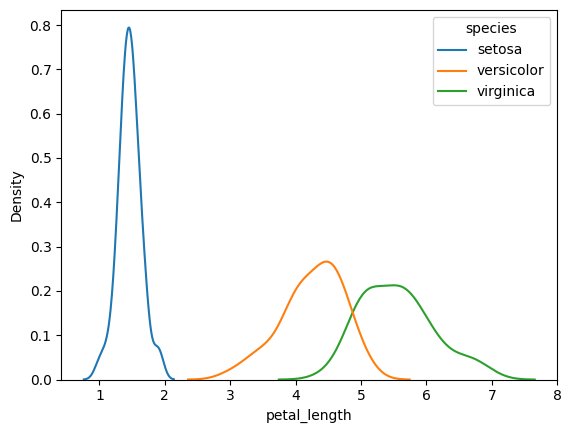

In [ ]:
sns.kdeplot(data=df, x='petal_length', hue='species')


<Axes: xlabel='petal_width', ylabel='Density'>

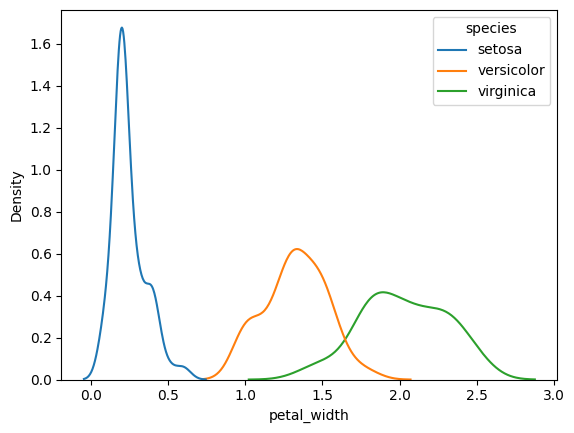

In [ ]:
sns.kdeplot(data=df, x='petal_width', hue='species')


<Axes: xlabel='sepal_length', ylabel='Density'>

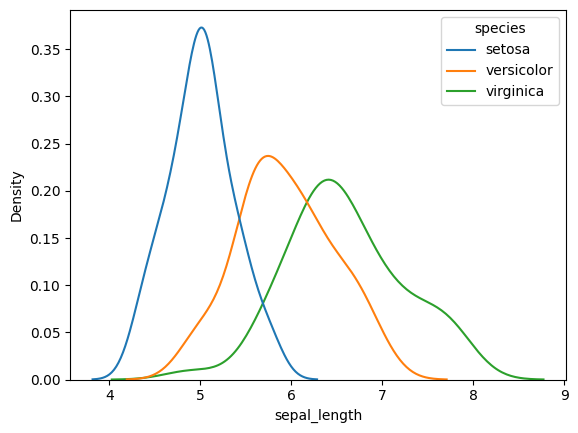

In [ ]:
sns.kdeplot(data=df, x='sepal_length', hue='species')


<Axes: xlabel='sepal_width', ylabel='Density'>

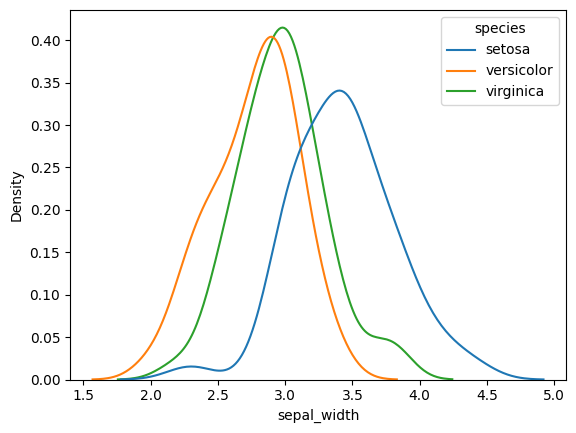

In [ ]:
sns.kdeplot(data=df, x='sepal_width', hue='species')


In [ ]:
titanic = sns.load_dataset('titanic')

<Axes: xlabel='age', ylabel='Density'>

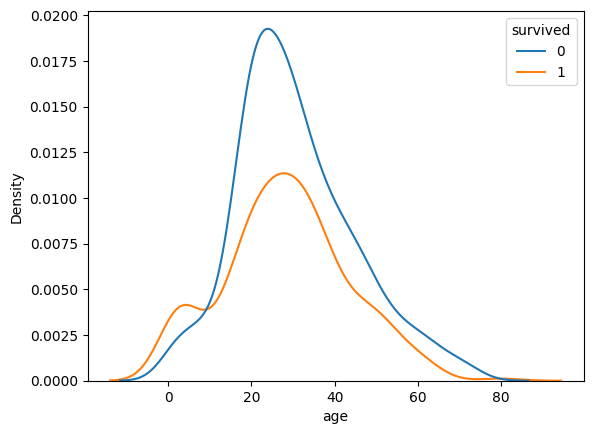

In [ ]:
sns.kdeplot(data = titanic, x = 'age', hue = 'survived')

<Axes: xlabel='petal_width', ylabel='Density'>

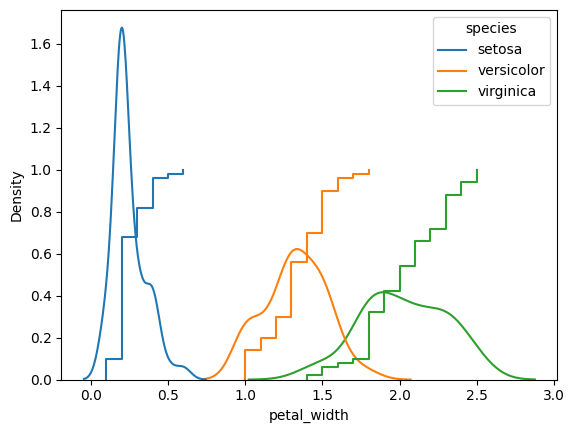

In [ ]:
sns.kdeplot(data=df, x='petal_width', hue='species')
sns.ecdfplot(data=df, x='petal_width', hue='species')

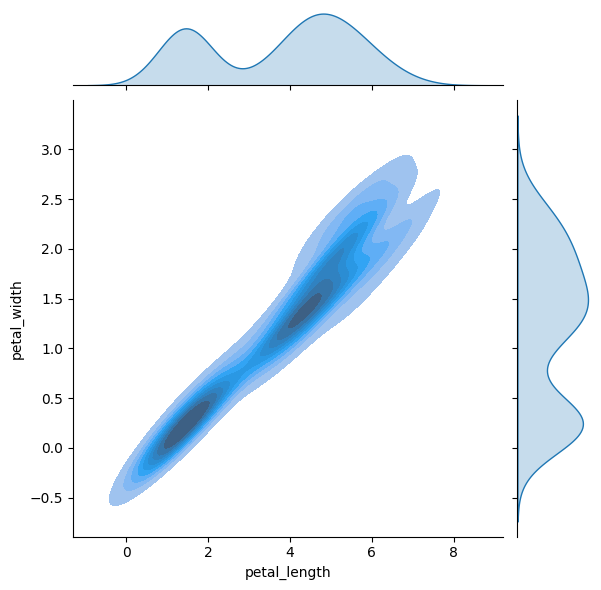

In [ ]:
sns.jointplot(data=df, x='petal_length', y='petal_width',kind=
'kde',fill = True)

<Axes: xlabel='age', ylabel='Density'>

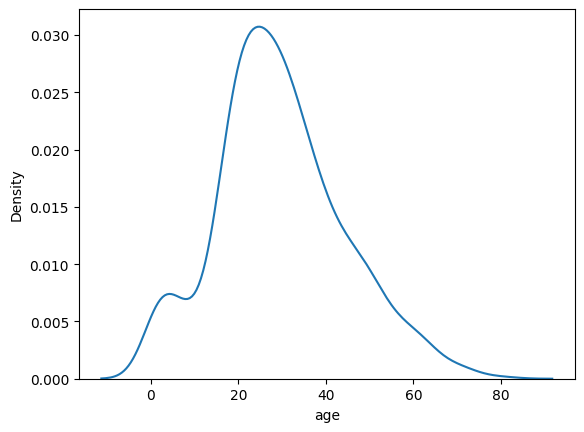

In [ ]:
sns.kdeplot(data = titanic, x = 'age')

In [ ]:
titanic['age'].mean()

np.float64(29.69911764705882)

In [ ]:
titanic['age'].std()

14.526497332334044

In [ ]:
x = (titanic['age']-titanic['age'].mean())/titanic['age'].std()

<Axes: xlabel='age', ylabel='Density'>

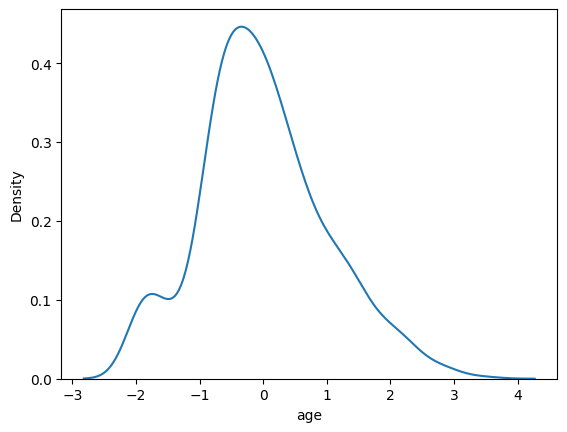

In [ ]:
sns.kdeplot(x)

In [ ]:
x.mean()

np.float64(2.388378943731429e-16)

In [ ]:
x.std()

0.9999999999999994

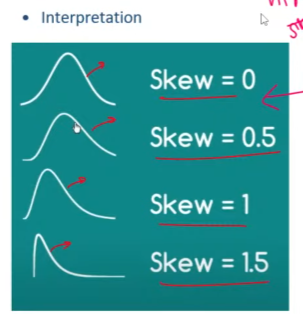

In [ ]:
x.skew() #-0.5 to 0.5 is normally distributed for practical purpose

np.float64(0.38910778230082615)

In [ ]:
titanic['age'].mean() - 3 *titanic['age'].std()

np.float64(-13.88037434994331)

In [ ]:
titanic['age'].mean() + 3 *titanic['age'].std()

np.float64(73.27860964406095)

In [ ]:
titanic[((titanic['age']> 73) | (titanic['age']<-13))]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.0,0,0,7.775,S,Third,man,True,NaN,Southampton,no,True


QQ plot:
A QQ plot is a graphical tool used to assess the similarity of the distribution of two sets of data

In [ ]:
temp = sorted(df['sepal_length'].tolist())

In [ ]:
y_quant = []
for i in range(1,101):
  y_quant.append(np.percentile(temp,i))

In [ ]:
samples = np.random.normal(loc = 0,scale = 1,size =1000)

In [ ]:
samples.mean()

np.float64(-0.00469423585788141)

In [ ]:
x_quant = []
for i in range(1,101):
  x_quant.append(np.percentile(samples,i))

<Axes: >

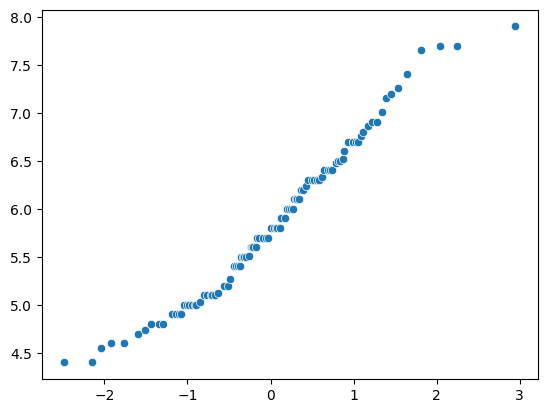

In [ ]:
sns.scatterplot(x= x_quant,y =y_quant)

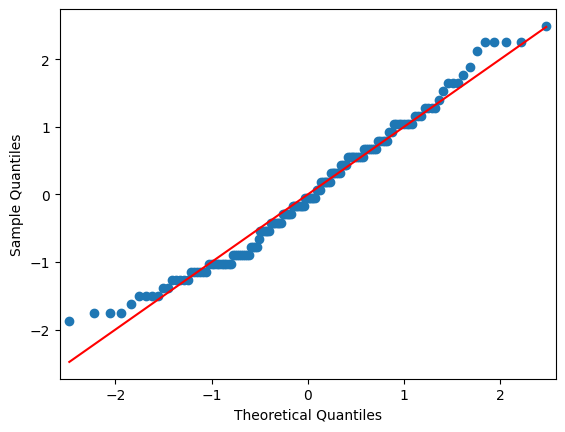

In [ ]:
#using statsmodel

import statsmodels.api as sm
import matplotlib.pyplot as plt

fig = sm.qqplot(df['sepal_length'], line ='s', fit =True)
plt.show()

Using qq plot to compare uniform distribution

In [ ]:
#sample distribution
x = np.random.uniform(low = 0,high = 1,size =1000)

(array([114.,  97., 101., 106.,  91.,  88., 103., 100., 102.,  98.]),
 array([0.0020345 , 0.10178047, 0.20152644, 0.3012724 , 0.40101837,
        0.50076434, 0.60051031, 0.70025627, 0.80000224, 0.89974821,
        0.99949418]),
 <BarContainer object of 10 artists>)

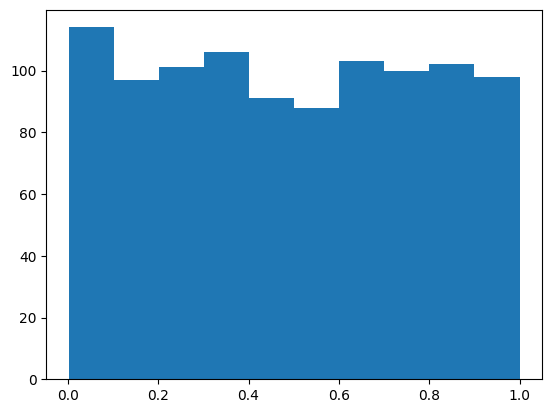

In [ ]:
plt.hist(x)

In [ ]:
#theoretical distribution
import scipy.stats as stats
params = stats.uniform.fit(x)
dist = stats.uniform(loc=params[0], scale=params[1])

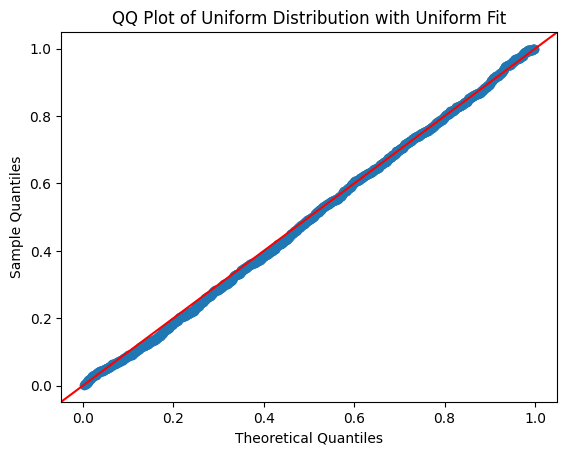

In [ ]:
# Creating a QQ plot of the data using the uniform distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Adding title and labels to the plot
plt.title('QQ Plot of Uniform Distribution with Uniform Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')


plt.show()

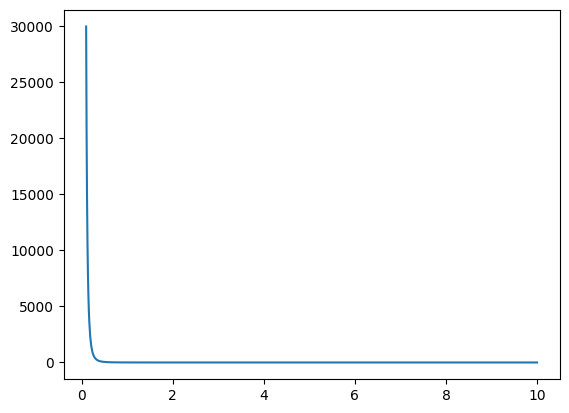

In [ ]:
# Log Log Plot
# Define the parameters of the Pareto distribution
alpha = 3
xm = 1

# Create an array of x values
x = np.linspace(0.1, 10, 1000)

# Calculate the y values of the Pareto distribution
y = alpha * (xm**alpha) / (x**(alpha+1))


plt.plot(x,y)

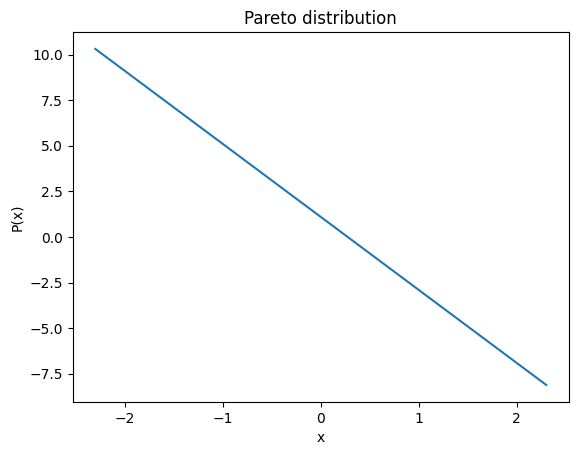

In [ ]:
# Create the log-log plot
plt.plot(np.log(x),np.log(y))

# Add labels and a title
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Pareto distribution')

# Show the plot
plt.show()

In [ ]:
# Define the parameters of the Pareto distribution
alpha = 2
xm = 1

# Generate a set of random data from the Pareto distribution
x = stats.pareto.rvs(b=alpha, scale=xm, size=1000)


(array([989.,   5.,   2.,   2.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1.00116493, 10.72720474, 20.45324455, 30.17928437, 39.90532418,
        49.631364  , 59.35740381, 69.08344363, 78.80948344, 88.53552325,
        98.26156307]),
 <BarContainer object of 10 artists>)

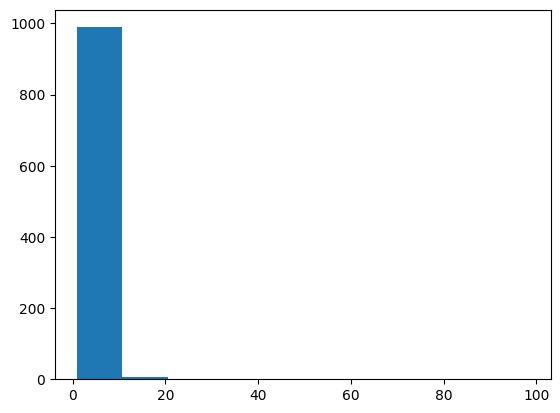

In [ ]:
plt.hist(x)

In [ ]:
# Fit a Pareto distribution to the data
params = stats.pareto.fit(x, floc=0)

# Create a Pareto distribution object with the fitted parameters
dist = stats.pareto(b=params[0], scale=params[2])


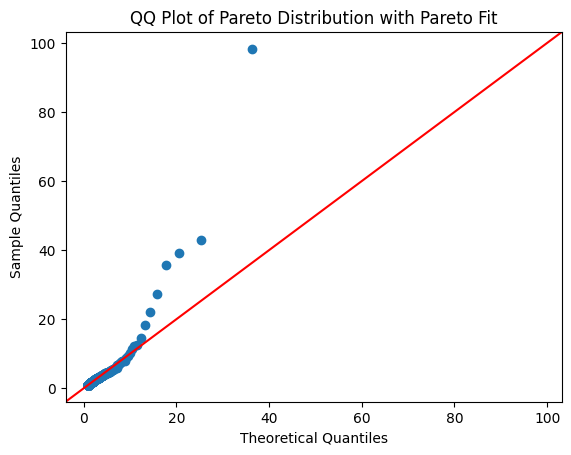

In [ ]:
# Create a QQ plot of the data using the Pareto distribution
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title and labels to the plot
plt.title('QQ Plot of Pareto Distribution with Pareto Fit')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Show the plot
plt.show()

